# Remove Background + Add new Background

### Pip

In [1]:
!pip install -q "transformers>=4.39.1,<5" huggingface_hub

In [2]:
!pip install torch torchvision
!pip install transformers huggingface_hub
!pip install einops kornia timm

## Imports

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import importlib
import src.ensemble

importlib.reload(src.ensemble)

<module 'src.ensemble' from '/content/drive/MyDrive/remove_background/src/ensemble.py'>

In [22]:
# --- системные ---
import sys
import os

project_path = "/content/drive/MyDrive/remove_background"
os.chdir(project_path)
sys.path.append(project_path)

# --- путь к проекту ---
# project_root = os.path.abspath("..")
# sys.path.append(project_root)

# --- базовые библиотеки ---
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- мой проект ---
from src.utils.io import load_image, save_image, load_mask
from src.matting import BiRefNetMattingModel, RMBGMattingModel
from src.compositing import apply_mask, replace_background
from src.metrics import binarize_mask, iou_score, dice_score, mad_score
from src.ensemble import ensemble_masks

## Data Load

In [5]:
images_dir = os.path.join(project_path, "data", "DUTS-TE", "DUTS-TE-Image")
masks_dir = os.path.join(project_path, "data", "DUTS-TE", "DUTS-TE-Mask")

image_files = sorted(os.listdir(images_dir))
mask_files = sorted(os.listdir(masks_dir))

print(len(image_files), len(mask_files))
print(image_files[:3])
print(mask_files[:3])

5019 5019
['ILSVRC2012_test_00000003.jpg', 'ILSVRC2012_test_00000023.jpg', 'ILSVRC2012_test_00000025.jpg']
['ILSVRC2012_test_00000003.png', 'ILSVRC2012_test_00000023.png', 'ILSVRC2012_test_00000025.png']


### Single load

In [6]:
image_name = image_files[0]
mask_name = os.path.splitext(image_name)[0] + ".png"

image_path = os.path.join(images_dir, image_name)
mask_path = os.path.join(masks_dir, mask_name)

print(image_path)
print(mask_path)

/content/drive/MyDrive/remove_background/data/DUTS-TE/DUTS-TE-Image/ILSVRC2012_test_00000003.jpg
/content/drive/MyDrive/remove_background/data/DUTS-TE/DUTS-TE-Mask/ILSVRC2012_test_00000003.png


In [7]:
image = load_image(image_path)
true_mask = load_mask(mask_path)

print("image:", image.shape, image.dtype)
print("true_mask:", true_mask.shape, true_mask.dtype, true_mask.min(), true_mask.max())

0 255
image: (302, 400, 3) uint8
true_mask: (302, 400) uint8 0 255


## Models

In [8]:
models_root = os.path.join(project_path, "models")

### BiRefNetMattingModel

In [9]:
model_birefnet = BiRefNetMattingModel(models_root=models_root)

In [10]:
pred_mask_birefnet = model_birefnet.predict_mask(image)

(302, 400) uint8 0 255


In [11]:
print("BiRefNet:", pred_mask_birefnet.shape, pred_mask_birefnet.dtype, pred_mask_birefnet.min(), pred_mask_birefnet.max())

BiRefNet: (302, 400) uint8 0 255


In [12]:
print("BiRefNet IoU:", iou_score(pred_mask_birefnet, true_mask))
print("BiRefNet Dice:", dice_score(pred_mask_birefnet, true_mask))
print("BiRefNet MAD:", mad_score(pred_mask_birefnet, true_mask))

BiRefNet IoU: 0.9613894333773989
BiRefNet Dice: 0.9803146861273154
BiRefNet MAD: 0.0077192574


### RMBGMattingModel

In [13]:
model_rmbg = RMBGMattingModel(models_root=models_root)

In [14]:
pred_mask_rmbg = model_rmbg.predict_mask(image)

(302, 400) uint8 0 255


In [15]:
print("RMBG:", pred_mask_rmbg.shape, pred_mask_rmbg.dtype, pred_mask_rmbg.min(), pred_mask_rmbg.max())

RMBG: (302, 400) uint8 0 255


In [16]:
print("RMBG IoU:", iou_score(pred_mask_rmbg, true_mask))
print("RMBG Dice:", dice_score(pred_mask_rmbg, true_mask))
print("RMBG MAD:", mad_score(pred_mask_rmbg, true_mask))

RMBG IoU: 0.9529411764705882
RMBG Dice: 0.9759036144578314
RMBG MAD: 0.0095525915


### Global Check

На тестовом примере обе модели показали высокое качество сегментации, однако BiRefNet продемонстрировал лучшие результаты по всем выбранным метрикам и был выбран как основной кандидат для дальнейшего использования в пайплайне.

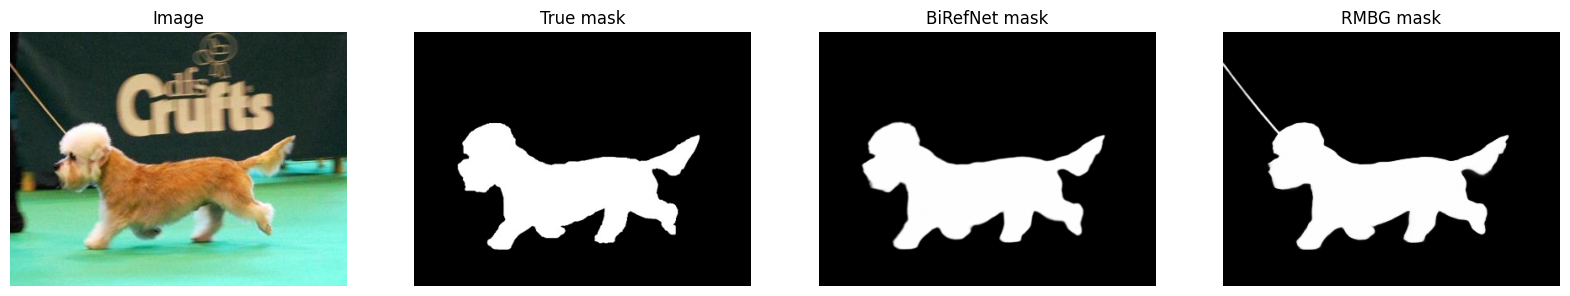

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(true_mask, cmap="gray")
axes[1].set_title("True mask")
axes[1].axis("off")

axes[2].imshow(pred_mask_birefnet, cmap="gray")
axes[2].set_title("BiRefNet mask")
axes[2].axis("off")

axes[3].imshow(pred_mask_rmbg, cmap="gray")
axes[3].set_title("RMBG mask")
axes[3].axis("off")

plt.show()

### Цикл по 10 изображений

In [18]:
results = []

N = 30

for i in range(N):
    image_name = image_files[i]
    mask_name = os.path.splitext(image_name)[0] + ".png"

    image_path = os.path.join(images_dir, image_name)
    mask_path = os.path.join(masks_dir, mask_name)

    # загрузка
    image = load_image(image_path)
    true_mask = load_mask(mask_path)

    # предсказания
    pred_biref = model_birefnet.predict_mask(image)
    pred_rmbg = model_rmbg.predict_mask(image)

    # метрики
    result = {
        "biref_iou": iou_score(pred_biref, true_mask),
        "biref_dice": dice_score(pred_biref, true_mask),
        "biref_mad": mad_score(pred_biref, true_mask),

        "rmbg_iou": iou_score(pred_rmbg, true_mask),
        "rmbg_dice": dice_score(pred_rmbg, true_mask),
        "rmbg_mad": mad_score(pred_rmbg, true_mask),
    }

    results.append(result)

    print(f"[{i+1}/{N}] done")

0 255
(302, 400) uint8 0 255
(302, 400) uint8 0 255
[1/10] done
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
[2/10] done
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
[3/10] done
0 255
(400, 323) uint8 0 255
(400, 323) uint8 0 255
[4/10] done
0 255
(400, 342) uint8 0 255
(400, 342) uint8 0 255
[5/10] done
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
[6/10] done
0 255
(400, 397) uint8 0 255
(400, 397) uint8 0 255
[7/10] done
0 255
(320, 400) uint8 0 255
(320, 400) uint8 0 255
[8/10] done
0 255
(400, 320) uint8 0 255
(400, 320) uint8 0 255
[9/10] done
0 255
(400, 267) uint8 0 255
(400, 267) uint8 0 255
[10/10] done


In [19]:
print("=== BiRefNet ===")
print("IoU:", np.mean([r["biref_iou"] for r in results]))
print("Dice:", np.mean([r["biref_dice"] for r in results]))
print("MAD:", np.mean([r["biref_mad"] for r in results]))

print("\n=== RMBG ===")
print("IoU:", np.mean([r["rmbg_iou"] for r in results]))
print("Dice:", np.mean([r["rmbg_dice"] for r in results]))
print("MAD:", np.mean([r["rmbg_mad"] for r in results]))

=== BiRefNet ===
IoU: 0.933690502826859
Dice: 0.9651422590006546
MAD: 0.009805443

=== RMBG ===
IoU: 0.9288153389852859
Dice: 0.9621932301401938
MAD: 0.011430512


In [20]:
biref_wins = sum(r["biref_iou"] > r["rmbg_iou"] for r in results)
rmbg_wins = sum(r["rmbg_iou"] > r["biref_iou"] for r in results)

print(f"BiRefNet wins: {biref_wins}")
print(f"RMBG wins: {rmbg_wins}")

BiRefNet wins: 6
RMBG wins: 4


BiRefNet немного опережает на 10 изображениях

In [23]:
pred_ens = ensemble_masks(pred_biref, pred_rmbg)

print("Ensemble IoU:", iou_score(pred_ens, true_mask))
print("Ensemble Dice:", dice_score(pred_ens, true_mask))
print("Ensemble MAD:", mad_score(pred_ens, true_mask))

Ensemble IoU: 0.9778829525803222
Ensemble Dice: 0.9888178178638811
Ensemble MAD: 0.012124625


In [24]:
results = []

for i in range(N):
    image_name = image_files[i]
    mask_name = os.path.splitext(image_name)[0] + ".png"

    image = load_image(os.path.join(images_dir, image_name))
    true_mask = load_mask(os.path.join(masks_dir, mask_name))

    pred_biref = model_birefnet.predict_mask(image)
    pred_rmbg = model_rmbg.predict_mask(image)

    pred_ens = ensemble_masks(pred_biref, pred_rmbg)

    results.append({
        "biref_iou": iou_score(pred_biref, true_mask),
        "rmbg_iou": iou_score(pred_rmbg, true_mask),
        "ens_iou": iou_score(pred_ens, true_mask),

        "biref_dice": dice_score(pred_biref, true_mask),
        "rmbg_dice": dice_score(pred_rmbg, true_mask),
        "ens_dice": dice_score(pred_ens, true_mask),

        "biref_mad": mad_score(pred_biref, true_mask),
        "rmbg_mad": mad_score(pred_rmbg, true_mask),
        "ens_mad": mad_score(pred_ens, true_mask),
    })

0 255
(302, 400) uint8 0 255
(302, 400) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(400, 323) uint8 0 255
(400, 323) uint8 0 255
0 255
(400, 342) uint8 0 255
(400, 342) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(400, 397) uint8 0 255
(400, 397) uint8 0 255
0 255
(320, 400) uint8 0 255
(320, 400) uint8 0 255
0 255
(400, 320) uint8 0 255
(400, 320) uint8 0 255
0 255
(400, 267) uint8 0 255
(400, 267) uint8 0 255


In [25]:
print("=== BiRefNet ===")
print("IoU:", np.mean([r["biref_iou"] for r in results]))
print("Dice:", np.mean([r["biref_dice"] for r in results]))
print("MAD:", np.mean([r["biref_mad"] for r in results]))

print("\n=== RMBG ===")
print("IoU:", np.mean([r["rmbg_iou"] for r in results]))
print("Dice:", np.mean([r["rmbg_dice"] for r in results]))
print("MAD:", np.mean([r["rmbg_mad"] for r in results]))

print("=== Ensemble ===")
print("IoU:", np.mean([r["ens_iou"] for r in results]))
print("Dice:", np.mean([r["ens_dice"] for r in results]))
print("MAD:", np.mean([r["ens_mad"] for r in results]))

=== BiRefNet ===
IoU: 0.933690502826859
Dice: 0.9651422590006546
MAD: 0.009805443

=== RMBG ===
IoU: 0.9288153389852859
Dice: 0.9621932301401938
MAD: 0.011430512
=== Ensemble ===
IoU: 0.936644753553235
Dice: 0.9668072732982591
MAD: 0.010255398


Ensemble подход позволил улучшить метрики IoU и Dice по сравнению с каждой моделью по отдельности, что свидетельствует о более точном выделении объекта. При этом наблюдается небольшое ухудшение MAD, что объясняется сглаживанием границ и накоплением ошибок от менее точной модели.

Попробую изменить немного веса

In [42]:
results = []
N = 30

for i in range(N):
    image_name = image_files[i]
    mask_name = os.path.splitext(image_name)[0] + ".png"

    image = load_image(os.path.join(images_dir, image_name))
    true_mask = load_mask(os.path.join(masks_dir, mask_name))

    pred_biref = model_birefnet.predict_mask(image)
    pred_rmbg = model_rmbg.predict_mask(image)

    pred_ens = ensemble_masks(pred_biref, pred_rmbg, 0.9, 0.1)

    results.append({
        "biref_iou": iou_score(pred_biref, true_mask),
        "rmbg_iou": iou_score(pred_rmbg, true_mask),
        "ens_iou": iou_score(pred_ens, true_mask),

        "biref_dice": dice_score(pred_biref, true_mask),
        "rmbg_dice": dice_score(pred_rmbg, true_mask),
        "ens_dice": dice_score(pred_ens, true_mask),

        "biref_mad": mad_score(pred_biref, true_mask),
        "rmbg_mad": mad_score(pred_rmbg, true_mask),
        "ens_mad": mad_score(pred_ens, true_mask),
    })

0 255
(302, 400) uint8 0 255
(302, 400) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(400, 323) uint8 0 255
(400, 323) uint8 0 255
0 255
(400, 342) uint8 0 255
(400, 342) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(400, 397) uint8 0 255
(400, 397) uint8 0 255
0 255
(320, 400) uint8 0 255
(320, 400) uint8 0 255
0 255
(400, 320) uint8 0 255
(400, 320) uint8 0 255
0 255
(400, 267) uint8 0 255
(400, 267) uint8 0 255
0 255
(308, 400) uint8 0 255
(308, 400) uint8 0 255
0 255
(274, 400) uint8 0 255
(274, 400) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(400, 326) uint8 0 255
(400, 326) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(300, 400) uint8 0 255
(300, 400) uint8 0 255
0 255
(400, 

In [43]:
print("=== BiRefNet ===")
print("IoU:", np.mean([r["biref_iou"] for r in results]))
print("Dice:", np.mean([r["biref_dice"] for r in results]))
print("MAD:", np.mean([r["biref_mad"] for r in results]))

print("\n=== RMBG ===")
print("IoU:", np.mean([r["rmbg_iou"] for r in results]))
print("Dice:", np.mean([r["rmbg_dice"] for r in results]))
print("MAD:", np.mean([r["rmbg_mad"] for r in results]))

print("=== Ensemble ===")
print("IoU:", np.mean([r["ens_iou"] for r in results]))
print("Dice:", np.mean([r["ens_dice"] for r in results]))
print("MAD:", np.mean([r["ens_mad"] for r in results]))

=== BiRefNet ===
IoU: 0.9458305960229546
Dice: 0.971825937386207
MAD: 0.00933431

=== RMBG ===
IoU: 0.9137844585296656
Dice: 0.9519418050438305
MAD: 0.017121352
=== Ensemble ===
IoU: 0.9462934130806967
Dice: 0.972075998051132
MAD: 0.010693703
